In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model
import numpy as np

In [25]:
df = pd.read_csv('housing.csv')

In [26]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


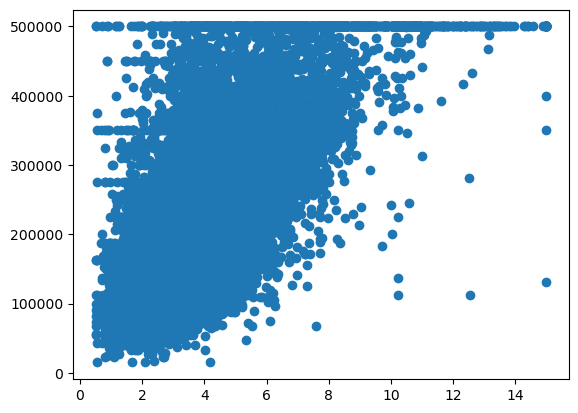

In [23]:
# Grafica income vs precio caa
plt.scatter(df.median_income, df.median_house_value)


In [28]:
# Elimina los máximos de precio casa
df1  = df.query("median_house_value < 500001")

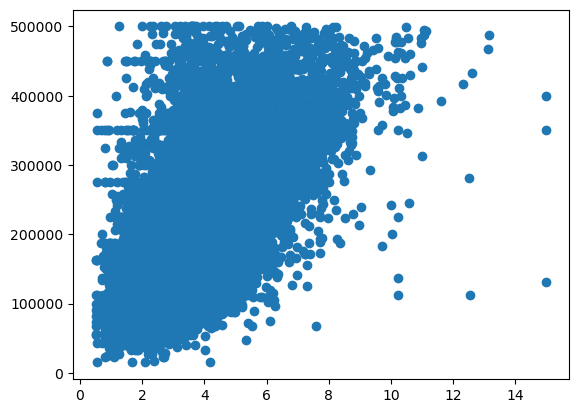

In [30]:
# Grafica sin los máximos
plt.scatter(df1.median_income, df1.median_house_value)

## Problema inicial: Quiero venderle casas a millonario, pero solo tengo datos de gente clase media, ¿cómo puedo estimar el valor de casas de millonarios?

Pista: es un tanto lógico, que a mayor ingreso mensual mayor precio de la casa. La casa de una familia con ingreso mensual de 6000 dolares en promedio vale menos que la de una de 10,000

In [32]:
# Crea una regreson lineal
model = linear_model.LinearRegression()

X = df1[['median_income']]
y = df1['median_house_value']

model.fit(X, y)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Intercepto : valor mínimo que va a valer una casa


In [33]:
model.intercept_

45456.99678231857

In [34]:
model.coef_

array([39987.01206231])

Coeficiente: Por cada 1,000 dolares más que gana una familia al mes, cuanto tiende a crecer el valor de su casa

$$ Precio = 45456 + 39987 *Income$$

$$Precio = \beta_0 + \beta_1 X $$

Mágicamente sklearn nos da esos numeros adaptados al problema, posteriormente ustedes verán como encontrar esos numeros 


Escribe la ecuacion:


$$Precio  = B_0 + B_1*ingreso$$

Llega un cliente millonario con ingreso mensual de 20,000 dolares y quiere vender su casa. 

¿Cuál es el precio?

In [35]:
45456 + 39987 * 20

845196

### ¿qué significan estos coeficientes?

$\beta_0$ =  X

$\beta_1$ =  Y

Cuando $\beta_1$ es 0 (es decir, el hogar no tiene ingresos) no tendría sentido decir que la casa no vale nada, las casas de la gente sin ingresos valen, por lo que la aproximación del modelo cuando la familia no tiene ingresos es de X

Para el caso de $\beta_1$ nos da que es Y, viendo la ecuación tiene que ver con que por cada mil dolares que la familia tenga extra de ingreso mensual, el precio de la casa debe aumentar Y


In [39]:
# ejemplo, familia de 4 mil dolares
f1 = 45456 + 39987 * 4

In [38]:
# Familia de 5 mil dolares
f2 = 45456 + 39987 * 5

In [40]:
## diferencia
f2 - f1

39987

In [11]:
## La diferencia es exactamente igual a la estimación beta del model 


## ¿Qué tan bueno es el modelo?

1- Recordando que el modelo es simplemente --> 𝑃𝑟𝑒𝑐𝑖𝑜=45456+39987∗𝑖𝑛𝑔𝑟𝑒𝑠𝑜

In [12]:
# Sin sklearn

In [41]:
predicciones = 45456 + 39987 * df1.median_income

In [47]:
np.mean((predicciones - y)**2)

5604611139.121405

In [46]:
# Scikit learn ya nos ahorra esto, nos da lo mismo
# Utilizaremos la función predict 
from sklearn.metrics import mean_squared_error

In [48]:
mean_squared_error(y_pred=predicciones, y_true=y)

5604611139.121405

In [50]:
predicciones = model.predict(X)

### Visualizando el modelo 

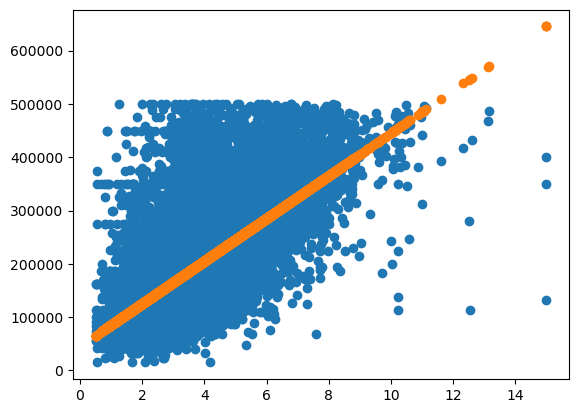

In [52]:
# Visualiza las predicciones del modelo 
plt.scatter(df1.median_income, df1.median_house_value)
plt.scatter(df1.median_income, predicciones)

Observamos que ya podemos tener un modelo para familias que ganan mucho dinero al mes (arriba de 13 mil dolares por ejemplo)

¿Cuanto vale el precio de una casa de una familia millonaria que gana 15 mil dolares al mes?

### Midiendo el modelo 

#### Error cuadrático medio 


¿Cuál es la diferencia entre las predicciones?

Ahhh pues saco el error promedio de esas diferencias

Sale un numero muy cerano a 0, ¿quiere decir que el modelo es buenisimo?

No realmente, lo que pasa es que hay negativos y positivos. Es mejor sacar las diferencias al cuadrado para eliminar esos sesgos

Listo, ya tenemos una medida ... pero no es tan interpretable porque viene de un cuadrado

Obtenemos la raíz cuadrada

También podemos usar el paquete

### R2 score 

Varianza de las casa = Varianza(precio de casas - promedio precios), representa la variabilidad total en los datos.

Varianza de las predicciones = Varianza(precio de casas - predicción), representa la variabilidad no explicada por el modelo

Uno pensaría, que si el modelo es bueno la varianza de las predicciones será mucho menor a la varianza de la casa (un modelo personalizado debe vencer a simplemente dar un promedio).


$$r^2 = \frac{\text{Var}(y) - \text{Var}(y - \text{predicciones})}{\text{Var}(y)}$$


In [53]:
vary = np.var(y)

In [54]:
var_y_minus_p = np.var(y - predicciones)

In [56]:
(vary - var_y_minus_p) / vary

0.4129486198582021

Utiliza sklearn para obtener el r2

In [57]:
from sklearn.metrics import r2_score

In [58]:
r2_score(y_pred=predicciones, y_true=y)

0.4129486198582022

Conceptualmente: el modelo es un 42% mejor que simplemente dar el precio promedio de las casas como estimación 

### Crea una regresión lineal para las distintas proximidades

In [69]:
# near bay 
X_ocean = df1[['ocean_proximity']]

In [70]:
X_ocean_dummys = pd.get_dummies(X_ocean)

In [73]:
# less 1 hour
X_inland = X_ocean_dummys[['ocean_proximity_INLAND']]

model = linear_model.LinearRegression()
model.fit(X_inland, y)
predicciones_inland = model.predict(X_inland)
r2_score(y_pred=predicciones_inland, y_true=y)


0.24900926262721235

In [75]:
# less 1 hour
X_latitude = df1[['latitude']]
model = linear_model.LinearRegression()
model.fit(X_latitude, y)
predicciones_latitude = model.predict(X_latitude)
r2_score(y_pred=predicciones_latitude, y_true=y)


0.021989717921782836

In [17]:
# less 1 hour


In [18]:
# less 1 hour


In [18]:
# less 1 hour


In [19]:
# Interpreta los coeficientes, que significan 